# Analyse du Data Drift — Modèle de scoring crédit

Ce notebook compare deux fenêtres temporelles de données de production :
- **Référence** : trafic simulé sans drift (distributions proches de l'entraînement)
- **Courant** : trafic simulé avec drift (distributions décalées pour simuler une dérive)

Les données sont chargées depuis la base PostgreSQL loggée par l'API.

Une fois l'API déployée, j'ai simulé deux fenêtres de trafic : une normale (proche des données d'entraînement) et une avec drift (distributions décalées). Ce notebook analyse d'abord les métriques opérationnelles (latence, erreurs), puis compare les distributions des features entre les deux fenêtres via Evidently et des tests KS, et conclut sur les actions à prendre.

## 1. Imports et configuration

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display
from evidently import Dataset, Report
from evidently.presets import DataDriftPreset

import sys
sys.path.insert(0, str(Path.cwd().parent))
load_dotenv(Path.cwd().parent / ".env")

from app.database import get_engine

warnings.filterwarnings("ignore")

# Features suivies (celles décalées par le script de simulation avec --drift)
FEATURES = [
    "DAYS_BIRTH",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "score",
]

REPORT_PATH = Path("reports/drift_report.html")
REPORT_PATH.parent.mkdir(exist_ok=True)

print("Configuration OK")

Configuration OK


## 2. Chargement des données depuis PostgreSQL

In [2]:
engine = get_engine()

cols = ", ".join(f'"{f}"' for f in FEATURES)

# Chargement de toutes les données avec timestamps pour détecter le gap
all_data = pd.read_sql(
    f'SELECT {cols}, "timestamp" FROM predictions ORDER BY "timestamp"',
    engine,
)
all_data["timestamp"] = pd.to_datetime(all_data["timestamp"], utc=True)
all_data["delta"] = all_data["timestamp"].diff()

# Le plus grand saut temporel = frontière entre les deux batches de simulation
cutoff_row = all_data["delta"].idxmax()
CUTOFF = all_data.loc[cutoff_row, "timestamp"]
gap_max = all_data["delta"].max()

assert gap_max > pd.Timedelta("1min"), (
    f"Pas de gap significatif détecté ({gap_max}). "
    "Relance les deux batches de simulation avec un délai entre eux."
)

reference = all_data[all_data["timestamp"] < CUTOFF][FEATURES].reset_index(drop=True)
current   = all_data[all_data["timestamp"] >= CUTOFF][FEATURES].reset_index(drop=True)

print(f"Coupure détectée automatiquement : {CUTOFF}")
print(f"Gap maximal entre deux requêtes  : {gap_max}")
print(f"Référence : {len(reference)} lignes")
print(f"Courant   : {len(current)} lignes")
display(reference.describe().round(2))

Coupure détectée automatiquement : 2026-04-27 11:02:04.276720+00:00
Gap maximal entre deux requêtes  : 0 days 03:39:30.062322
Référence : 101 lignes
Courant   : 100 lignes


,DAYS_BIRTH,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,score
count,101.00,101.00,101.00,101.00,46.00,101.00,83.00,101.00
mean,-15965.74,164095.58,634382.75,25273.82,0.49,0.50,0.51,0.33
std,4962.02,87650.10,507750.05,21646.37,0.22,0.19,0.22,0.17
min,-24767.80,1.00,1.00,1.00,0.00,0.00,0.00,0.06
25%,-20578.90,102278.84,294745.36,10094.20,0.33,0.39,0.38,0.20
50%,-15973.00,148340.26,498833.58,19322.56,0.49,0.50,0.49,0.28
75%,-11535.80,202826.63,895001.46,34776.74,0.63,0.65,0.67,0.43
max,-1.00,632181.13,3596562.08,151601.72,0.93,0.99,0.99,0.88


> **Note sur le choix des données de référence**
>
> Dans un contexte de production idéal, la fenêtre de référence proviendrait directement du jeu d'entraînement du modèle (données historiques étiquetées issues du projet MLOps partie 1). Ici, nous utilisons la **première fenêtre de trafic de production simulée** (sans drift) comme proxy stable, car :
> - Sa distribution est proche des données d'entraînement (simulation fidèle au jeu original)
> - Elle représente le comportement "normal" de l'API en démarrage
>
> Cette approche est valide en phase de démarrage avant d'avoir suffisamment de labels en production. À terme, la référence devrait être mise à jour périodiquement avec des données étiquetées.

## 3. Métriques opérationnelles

,Requêtes,Taux erreur %,Latence moy (ms),Latence p95 (ms),Latence p99 (ms),Latence max (ms)
Fenêtre,,,,,,
Référence,106,0.94,56.1,53.1,424.0,1471.0
Courant,100,0.00,58.6,47.8,717.7,1352.6


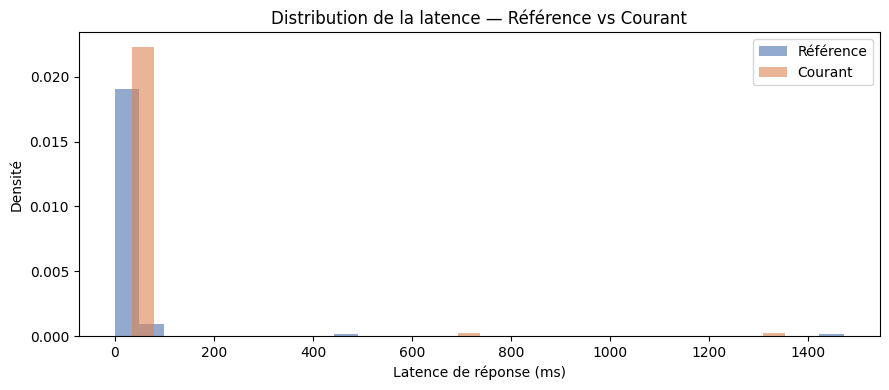

Graphique sauvegardé : reports/latency_distribution.png


In [3]:
# Chargement des logs depuis la table dédiée
all_logs = pd.read_sql(
    'SELECT timestamp, response_time_ms, status_code, endpoint FROM logs ORDER BY timestamp',
    engine,
)
all_logs["timestamp"] = pd.to_datetime(all_logs["timestamp"], utc=True)

logs_ref = all_logs[all_logs["timestamp"] < CUTOFF]
logs_cur = all_logs[all_logs["timestamp"] >= CUTOFF]

rows = []
for label, logs in [("Référence", logs_ref), ("Courant", logs_cur)]:
    n = len(logs)
    errors = (logs["status_code"] >= 400).sum()
    rows.append({
        "Fenêtre":         label,
        "Requêtes":        n,
        "Taux erreur %":   round(errors / n * 100, 2) if n > 0 else 0,
        "Latence moy (ms)": round(logs["response_time_ms"].mean(), 1),
        "Latence p95 (ms)": round(logs["response_time_ms"].quantile(0.95), 1),
        "Latence p99 (ms)": round(logs["response_time_ms"].quantile(0.99), 1),
        "Latence max (ms)": round(logs["response_time_ms"].max(), 1),
    })

ops_df = pd.DataFrame(rows).set_index("Fenêtre")
display(ops_df)

# Visualisation de la distribution de la latence
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(logs_ref["response_time_ms"], bins=30, alpha=0.6, label="Référence", color="#4C72B0", density=True)
ax.hist(logs_cur["response_time_ms"], bins=30, alpha=0.6, label="Courant",   color="#DD8452", density=True)
ax.set_xlabel("Latence de réponse (ms)")
ax.set_ylabel("Densité")
ax.set_title("Distribution de la latence — Référence vs Courant")
ax.legend()
plt.tight_layout()
plt.savefig("reports/latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : reports/latency_distribution.png")

## 4. Rapport Evidently — Détection de drift

In [4]:
report = Report([DataDriftPreset()])
result = report.run(
    Dataset.from_pandas(reference),
    Dataset.from_pandas(current),
)

result.save_html(str(REPORT_PATH))
print(f"Rapport interactif exporté : {REPORT_PATH.resolve()}")
print("→ Ouvrir ce fichier dans un navigateur pour la visualisation complète Evidently.")

Rapport interactif exporté : /home/rapha/ai-engineer/credit-scoring-mlops-production/monitoring/reports/drift_report.html
→ Ouvrir ce fichier dans un navigateur pour la visualisation complète Evidently.


In [5]:
summary = pd.DataFrame({
    "mean_ref":    reference.mean(numeric_only=True).round(3),
    "mean_cur":    current.mean(numeric_only=True).round(3),
    "std_ref":     reference.std(numeric_only=True).round(3),
    "std_cur":     current.std(numeric_only=True).round(3),
})
summary["delta_mean_%"] = ((summary["mean_cur"] - summary["mean_ref"]) / summary["mean_ref"].abs() * 100).round(1)

display(summary)

,mean_ref,mean_cur,std_ref,std_cur,delta_mean_%
DAYS_BIRTH,-15965.743,-20397.954,4962.022,4215.892,-27.8
AMT_INCOME_TOTAL,164095.579,116746.778,87650.099,52673.533,-28.9
AMT_CREDIT,634382.753,624812.338,507750.046,345895.216,-1.5
AMT_ANNUITY,25273.818,41221.083,21646.370,24384.600,63.1
EXT_SOURCE_1,0.494,0.384,0.219,0.202,-22.3
EXT_SOURCE_2,0.504,0.323,0.195,0.164,-35.9
EXT_SOURCE_3,0.513,0.350,0.220,0.156,-31.8
score,0.331,0.508,0.167,0.173,53.5


## 5. Tests statistiques (Kolmogorov-Smirnov) et visualisations

Le test de Kolmogorov-Smirnov compare les distributions empiriques de deux échantillons.
- **Hypothèse nulle H₀** : les deux échantillons proviennent de la même distribution
- **Seuil** : si `p-value < 0.05`, on rejette H₀ → drift statistiquement significatif

In [6]:
ks_results = []
for feat in FEATURES:
    ref_vals = reference[feat].dropna()
    cur_vals = current[feat].dropna()
    ks_stat, pvalue = stats.ks_2samp(ref_vals, cur_vals)
    drift_detected = pvalue < 0.05
    ks_results.append({
        "Feature":       feat,
        "KS stat":       round(ks_stat, 3),
        "p-value":       round(pvalue, 4),
        "Drift détecté": "OUI ⚠️" if drift_detected else "NON ✓",
    })

ks_df = pd.DataFrame(ks_results).set_index("Feature")
display(ks_df)

n_drift = ks_df["Drift détecté"].str.startswith("OUI").sum()
print(f"\n{n_drift}/{len(FEATURES)} features en drift significatif (p < 0.05)")

,KS stat,p-value,Drift détecté
Feature,,,
DAYS_BIRTH,0.374,0.0000,OUI ⚠️
AMT_INCOME_TOTAL,0.315,0.0000,OUI ⚠️
AMT_CREDIT,0.138,0.2494,NON ✓
AMT_ANNUITY,0.375,0.0000,OUI ⚠️
EXT_SOURCE_1,0.292,0.0255,OUI ⚠️
EXT_SOURCE_2,0.444,0.0000,OUI ⚠️
EXT_SOURCE_3,0.395,0.0000,OUI ⚠️
score,0.414,0.0000,OUI ⚠️



7/8 features en drift significatif (p < 0.05)


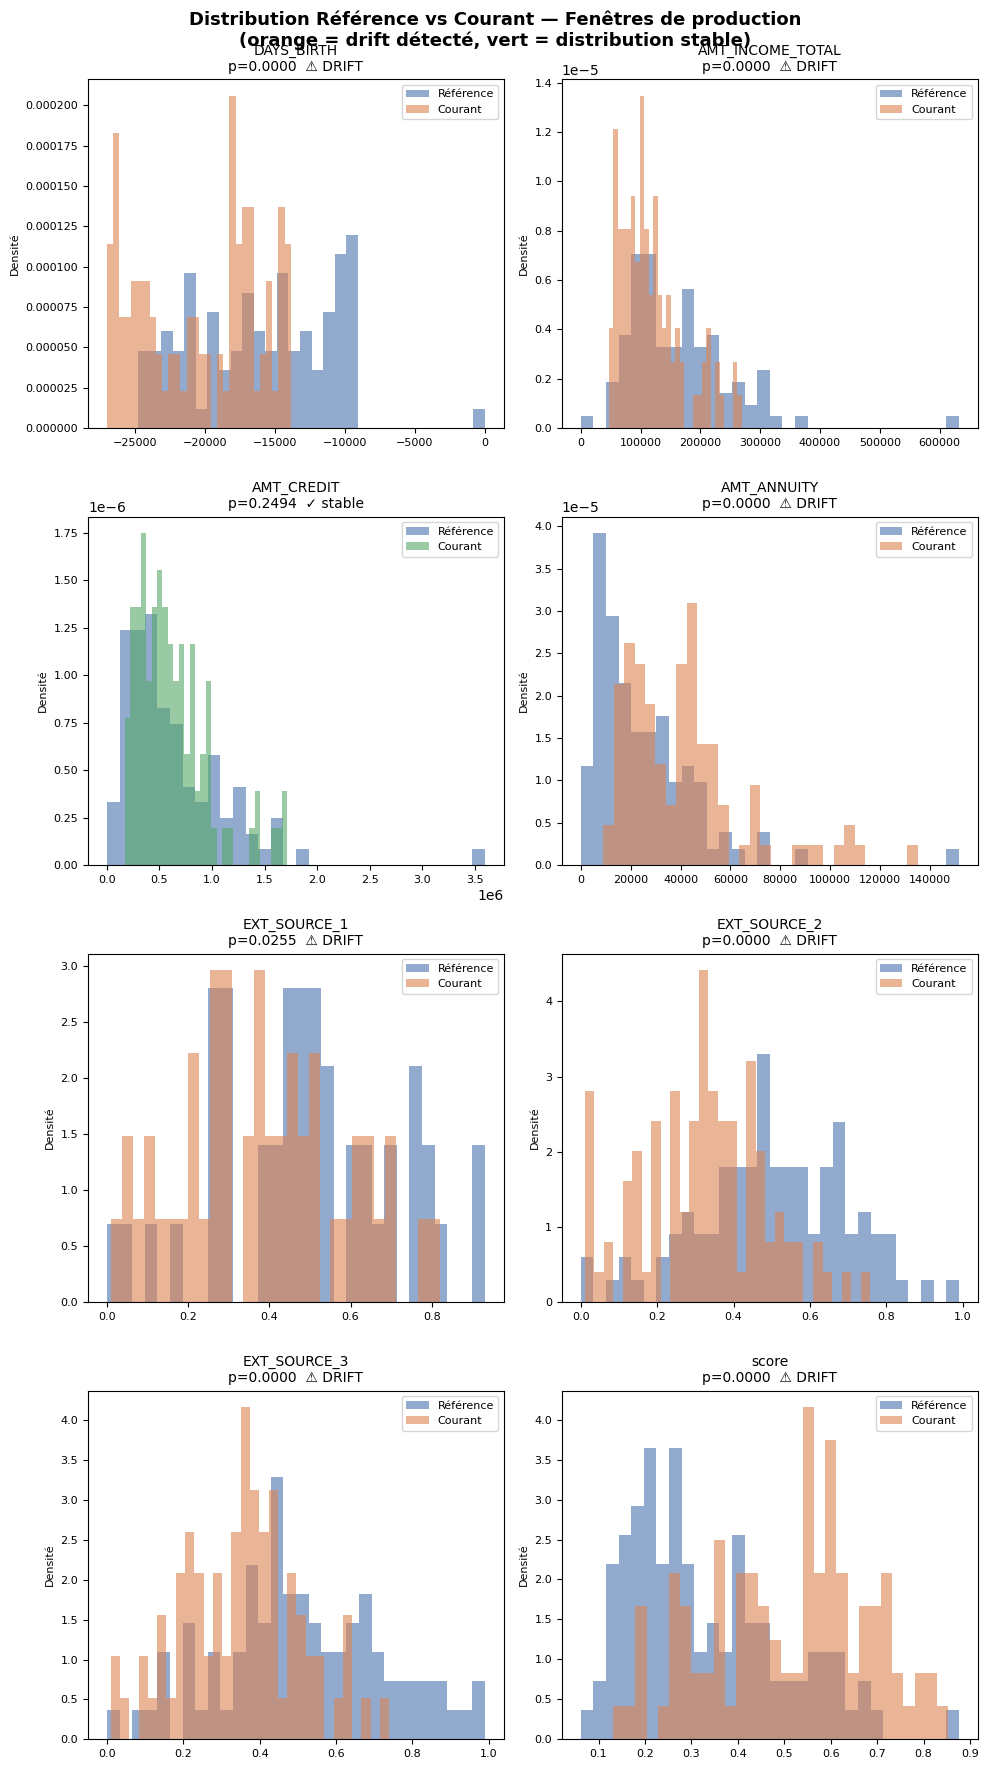

Graphique sauvegardé : reports/distributions_drift.png


In [8]:
fig, axes = plt.subplots(4, 2, figsize=(10, 18))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ref_vals = reference[feat].dropna()
    cur_vals = current[feat].dropna()
    _, pvalue = stats.ks_2samp(ref_vals, cur_vals)
    drift = pvalue < 0.05

    color_cur = "#DD8452" if drift else "#55A868"
    status    = "⚠️ DRIFT" if drift else "✓ stable"

    axes[i].hist(ref_vals, bins=30, alpha=0.6, label="Référence", color="#4C72B0", density=True)
    axes[i].hist(cur_vals, bins=30, alpha=0.6, label="Courant",   color=color_cur,  density=True)
    axes[i].set_title(f"{feat}\np={pvalue:.4f}  {status}", fontsize=10)
    axes[i].set_ylabel("Densité", fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

plt.suptitle(
    "Distribution Référence vs Courant — Fenêtres de production\n"
    "(orange = drift détecté, vert = distribution stable)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("reports/distributions_drift.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : reports/distributions_drift.png")

## 6. Interprétation et recommandations

### Features en drift

Le script `simulate_production.py --drift` applique les décalages suivants :

| Feature | Décalage simulé | Impact attendu |
|---|---|---|
| `DAYS_BIRTH` | Clients plus âgés (+12 ans en moyenne) | Changement de profil démographique |
| `AMT_INCOME_TOTAL` | Revenus réduits de 20 à 40% | Profils financièrement plus fragiles |
| `AMT_CREDIT` | Durée de crédit allongée (36–96 mois vs 12–72) | Montants empruntés plus élevés |
| `AMT_ANNUITY` | Taux d'annuité plus élevé (5–8.5% vs 2.5–5.5%) | Charge de remboursement plus lourde |
| `EXT_SOURCE_1/2/3` | Scores externes décalés de -0.18 | Historique crédit plus risqué |
| `score` | Score de défaut plus élevé (attendu) | Conséquence directe du drift des features |

### Ce que ça signifie en production

Si ce drift se produisait réellement, l'API recevrait des profils **systématiquement plus risqués** que ceux sur lesquels le modèle a été entraîné. 

Le premier problème est une possible sous-estimation du risque : le modèle a été calibré sur d'autres distributions, ses scores de défaut pourraient ne plus être fiables pour ces nouveaux profils.

Le second est plus indirect : le taux de rejet monte mécaniquement, ce qui peut fausser les métriques métier et donner l'impression que le modèle devient plus sévère alors que c'est la population qui change.

### Métriques opérationnelles

Les métriques de latence et de taux d'erreur (section 3) permettent de détecter des **anomalies infrastructurelles** indépendantes du drift : surcharge serveur, dégradation de l'API, erreurs de validation. Un taux d'erreur > 1% ou une latence p99 > 500ms doivent déclencher une alerte.

### Actions recommandées

| Horizon | Action |
|---|---|
| Court terme | Surveiller hebdomadairement la distribution des scores et le taux de rejet |
| Moyen terme | Si drift confirmé sur données réelles, déclencher un ré-entraînement sur données récentes |
| Seuil d'alerte | Drift détecté sur **≥ 3 features clés** (`EXT_SOURCE_*`, `AMT_INCOME_TOTAL`, `DAYS_BIRTH`) → revue manuelle obligatoire |